# 📊 Student Scores — Full Analysis Notebook
**Dataset:** `Scores.csv` · TU Dortmund M.Sc. Data Science Application WS 2026/27  
**Theme:** TU Dortmund official brand colours  

| Section | Content |
|---|---|
| 0 | Install Dependencies |
| 1 | Setup & TU Dortmund Theme |
| 2 | Data Loading & Sanity Checks |
| 3 | Descriptive Statistics |
| 4 | Visualisations |
| 5 | Assumption Checks |
| 6 | Gender Hypothesis Tests (RQ1) |
| 7 | Parental Education Hypothesis Tests (RQ2) |
| 8 | Effect Sizes |
| 9 | Results Summary |

> ⚠️ Place `Scores.csv` in the same folder as this notebook before running.  
> Run cells **top-to-bottom**.  
> Figures are saved to `figures/` as both `.pdf` and `.png`.


## 0 · Install Dependencies

In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scipy statsmodels scikit-posthocs --quiet
print("✓ All packages ready")

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

✓ All packages ready


## 1 · Setup & TU Dortmund Theme

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scikit_posthocs as sp
import warnings
warnings.filterwarnings("ignore")

os.makedirs("figures", exist_ok=True)

print("✓ Libraries loaded")
print("✓ figures/ directory ready")

✓ Libraries loaded
✓ figures/ directory ready


In [3]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  TU DORTMUND OFFICIAL BRAND PALETTE
#  Primary green: #84B818  (Pantone 368 M · CMYK 57-0-100-0)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

TUD = {
    "green":        "#84B818",
    "green_dark":   "#5A7D10",
    "green_mid":    "#A0CC45",
    "green_light":  "#C8E07A",
    "green_pale":   "#EBF5CC",
    "charcoal":     "#1C1C1C",
    "slate":        "#5A5A5A",
    "silver":       "#D0D0D0",
    "white":        "#FFFFFF",
    "bg":           "#F7F9F2",
    "accent":       "#C4940A",
    "accent_light": "#F0C84A",
}

GENDER_COLORS = {
    "female": TUD["green_dark"],
    "male":   TUD["accent"],
}

EDU_COLORS = [TUD["green_pale"], TUD["green_light"], TUD["green_mid"], TUD["green"]]
EDU_ORDER  = ["high school", "associate's degree", "bachelor's degree", "master's degree"]
EDU_LABELS = ["High School", "Associate's", "Bachelor's", "Master's"]

plt.rcParams.update({"font.family": "sans-serif", "font.size": 10})

def style_ax(ax, title="", xlabel="", ylabel="Score"):
    ax.set_facecolor(TUD["bg"])
    ax.set_title(title, fontsize=13, fontweight="bold", color=TUD["charcoal"], pad=8)
    ax.set_xlabel(xlabel, fontsize=11, color=TUD["slate"])
    ax.set_ylabel(ylabel, fontsize=11, color=TUD["slate"])
    ax.tick_params(labelsize=10, colors=TUD["slate"])
    ax.yaxis.grid(True, linestyle=":", color=TUD["silver"], alpha=0.9, linewidth=0.8)
    ax.set_axisbelow(True)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    for sp in ["left", "bottom"]:
        ax.spines[sp].set_color(TUD["silver"])
        ax.spines[sp].set_linewidth(0.8)

BP_PROPS = dict(
    patch_artist=True, widths=0.45, notch=False,
    medianprops=dict(color=TUD["charcoal"], linewidth=2.2),
    whiskerprops=dict(linewidth=1.2, color=TUD["slate"]),
    capprops=dict(linewidth=1.2, color=TUD["slate"]),
    flierprops=dict(marker="o", markersize=3.5, alpha=0.35,
                    markerfacecolor=TUD["slate"], linestyle="none"),
)

def save_fig(name):
    plt.savefig(f"figures/{name}.pdf", bbox_inches="tight", facecolor=TUD["white"])
    plt.savefig(f"figures/{name}.png", dpi=300, bbox_inches="tight", facecolor=TUD["white"])
    print(f"✓ figures/{name}.pdf  +  figures/{name}.png  saved")

print("✓ TU Dortmund theme ready")

✓ TU Dortmund theme ready


## 2 · Data Loading & Sanity Checks

In [4]:
df = pd.read_csv("Scores.csv", sep=";", index_col=0, decimal=",")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(8)

Shape: 972 rows × 5 columns


,student_id,gender,parental.level.of.education,subject,score
1,id_001,female,high school,math,23.0
2,id_001,female,high school,language,40.0
3,id_002,female,high school,math,68.0
4,id_002,female,high school,language,80.5
5,id_003,male,high school,math,82.0
6,id_003,male,high school,language,81.0
7,id_004,female,high school,math,58.0
8,id_004,female,high school,language,60.5


In [5]:
print("── Column dtypes ──────────────────────────────────")
print(df.dtypes)
print()
print("── Missing values ─────────────────────────────────")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

── Column dtypes ──────────────────────────────────
student_id                         str
gender                             str
parental.level.of.education        str
subject                            str
score                          float64
dtype: object

── Missing values ─────────────────────────────────
student_id                     0
gender                         0
parental.level.of.education    0
subject                        0
score                          0
dtype: int64

Total missing: 0


In [6]:
print("── Categorical value counts ───────────────────────")
for col in ["gender", "subject", "parental.level.of.education"]:
    print(f"\n{col}:")
    for k, v in df[col].value_counts().items():
        print(f"  {k:<30}  {v:>4}  ({100*v/len(df):.1f}%)")

── Categorical value counts ───────────────────────

gender:
  female                           490  (50.4%)
  male                             482  (49.6%)

subject:
  math                             486  (50.0%)
  language                         486  (50.0%)

parental.level.of.education:
  associate's degree               354  (36.4%)
  high school                      312  (32.1%)
  bachelor's degree                188  (19.3%)
  master's degree                  118  (12.1%)


In [7]:
print("── Score summary ──────────────────────────────────")
print(df["score"].describe().round(2).to_string())
print(f"\nUnique students : {df['student_id'].nunique()}")
print(f"Rows per student: {df.groupby('student_id').size().unique().tolist()} (expected [2])")

── Score summary ──────────────────────────────────
count    972.00
mean      67.69
std       14.80
min       19.50
25%       57.00
50%       68.00
75%       78.00
max      100.00

Unique students : 486
Rows per student: [2] (expected [2])


In [8]:
pivot = df.pivot_table(index="student_id", columns="subject",
                        values="score", aggfunc="count")
ok = (pivot == 1).all(axis=1).all()
print(f"Every student has exactly 1 math + 1 language row: {ok}",
      "✓" if ok else "⚠️ CHECK FAILED")

Every student has exactly 1 math + 1 language row: True ✓


## 3 · Descriptive Statistics

In [9]:
math = df[df["subject"] == "math"].copy()
lang = df[df["subject"] == "language"].copy()
print(f"Math rows: {len(math)}  |  Language rows: {len(lang)}")

Math rows: 486  |  Language rows: 486


In [10]:
def describe_group(s):
    return pd.Series({
        "n":      int(len(s)),
        "mean":   round(s.mean(), 2),
        "median": round(s.median(), 2),
        "std":    round(s.std(), 2),
        "Q1":     round(s.quantile(0.25), 2),
        "Q3":     round(s.quantile(0.75), 2),
        "IQR":    round(s.quantile(0.75) - s.quantile(0.25), 2),
        "min":    round(s.min(), 2),
        "max":    round(s.max(), 2),
    })

rows = []
for subj, sdf in [("Mathematics", math), ("Language", lang)]:
    for g in ["female", "male"]:
        r = describe_group(sdf[sdf["gender"] == g]["score"])
        r["Subject"], r["Gender"] = subj, g
        rows.append(r)

desc_gender = (pd.DataFrame(rows)
               .set_index(["Subject", "Gender"])
               [["n","mean","median","std","Q1","Q3","IQR","min","max"]])
print("── Descriptive stats: Subject × Gender ───────────────────────────────────")
desc_gender

── Descriptive stats: Subject × Gender ───────────────────────────────────


n   mean  median    std    Q1    Q3   IQR   min    max
Subject     Gender                                                            
Mathematics female  245.0  63.86    64.0  15.26  54.0  74.0  20.0  23.0  100.0
            male    241.0  68.95    70.0  14.43  58.0  80.0  22.0  30.0  100.0
Language    female  245.0  73.00    73.0  14.01  64.0  82.5  18.5  29.5  100.0
            male    241.0  64.93    65.5  13.75  54.0  75.0  21.0  19.5  100.0

In [11]:
rows = []
for subj, sdf in [("Mathematics", math), ("Language", lang)]:
    for e in EDU_ORDER:
        r = describe_group(sdf[sdf["parental.level.of.education"] == e]["score"])
        r["Subject"], r["Education"] = subj, e
        rows.append(r)

desc_edu = (pd.DataFrame(rows)
            .set_index(["Subject", "Education"])
            [["n","mean","median","std","Q1","Q3","IQR"]])
print("── Descriptive stats: Subject × Parental Education ───────────────────────")
desc_edu

── Descriptive stats: Subject × Parental Education ───────────────────────


n   mean  median    std     Q1     Q3  \
Subject     Education                                                       
Mathematics high school         156.0  62.24    63.0  14.04  53.75  71.00   
            associate's degree  177.0  67.81    66.0  15.24  57.00  81.00   
            bachelor's degree    94.0  68.44    67.0  15.05  61.00  77.75   
            master's degree      59.0  69.75    73.0  15.15  55.50  81.00   
Language    high school         156.0  63.53    65.0  13.40  53.38  73.00   
            associate's degree  177.0  70.02    72.0  14.21  59.00  79.00   
            bachelor's degree    94.0  72.06    73.0  14.27  63.12  80.38   
            master's degree      59.0  75.53    76.0  13.55  66.25  85.75   

                                  IQR  
Subject     Education                  
Mathematics high school         17.25  
            associate's degree  24.00  
            bachelor's degree   16.75  
            master's degree     25.50  
Language    high school         19.62  
            associate's degree  20.00  
            bachelor's degree   17.25  
            master's degree     19.50

## 4 · Visualisations
All figures use the **TU Dortmund palette**.  
Saved to `figures/` as **`.pdf`** (for LaTeX) and **`.png`** (dpi=300).  
Note: no figure numbers in plot titles — LaTeX captions handle numbering.


✓ figures/fig1_histograms.pdf  +  figures/fig1_histograms.png  saved


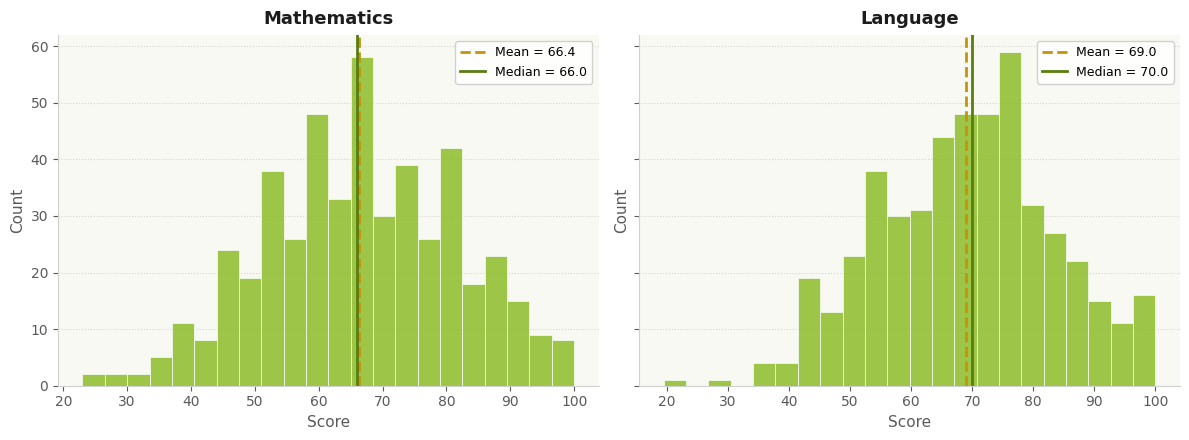

In [12]:
# ── Figure 1: Score histograms by subject ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
fig.patch.set_facecolor(TUD["white"])

for ax, (sdf, title) in zip(axes, [(math, "Mathematics"), (lang, "Language")]):
    ax.hist(sdf["score"], bins=22, color=TUD["green"], alpha=0.78,
            edgecolor=TUD["white"], linewidth=0.6)
    ax.axvline(sdf["score"].mean(),   color=TUD["accent"],    lw=2, ls="--",
               label=f"Mean = {sdf['score'].mean():.1f}")
    ax.axvline(sdf["score"].median(), color=TUD["green_dark"], lw=2, ls="-",
               label=f"Median = {sdf['score'].median():.1f}")
    style_ax(ax, title=title, xlabel="Score", ylabel="Count")
    ax.legend(fontsize=9, framealpha=0.9)

fig.tight_layout()
save_fig("fig1_histograms")
plt.show()

✓ figures/fig2_gender_boxplots.pdf  +  figures/fig2_gender_boxplots.png  saved


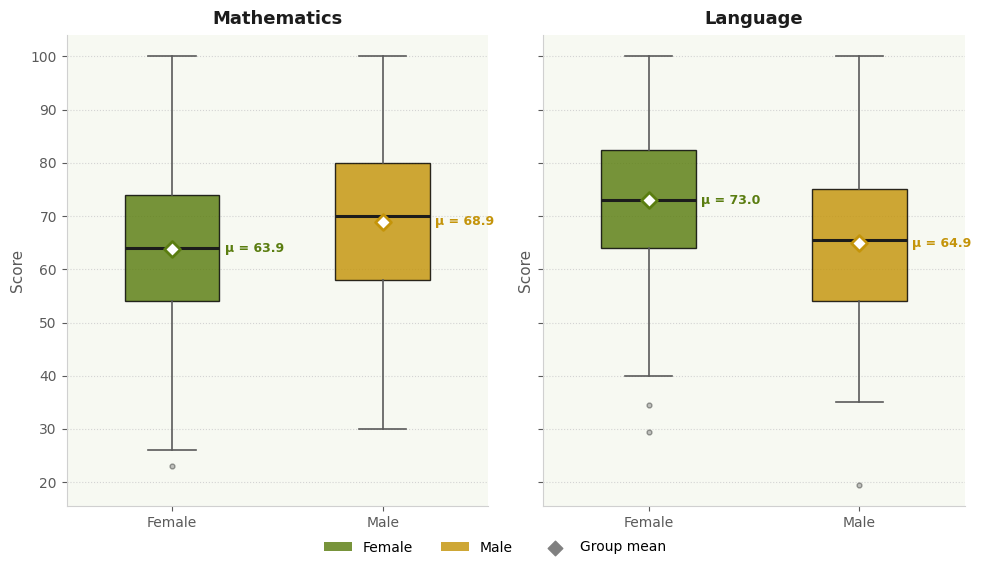

In [13]:
# ── Figure 2: Boxplots — gender × subject ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 5.5), sharey=True)
fig.patch.set_facecolor(TUD["white"])

for ax, (sdf, title) in zip(axes, [(math, "Mathematics"), (lang, "Language")]):
    f = sdf[sdf["gender"] == "female"]["score"]
    m = sdf[sdf["gender"] == "male"]["score"]
    bp = ax.boxplot([f, m], **BP_PROPS)
    bp["boxes"][0].set_facecolor(GENDER_COLORS["female"]); bp["boxes"][0].set_alpha(0.82)
    bp["boxes"][1].set_facecolor(GENDER_COLORS["male"]);   bp["boxes"][1].set_alpha(0.82)
    for i, (d, c) in enumerate([(f, GENDER_COLORS["female"]),
                                  (m, GENDER_COLORS["male"])], start=1):
        ax.scatter(i, d.mean(), marker="D", color=TUD["white"],
                   edgecolors=c, linewidths=2, zorder=6, s=65)
        ax.text(i + 0.25, d.mean(), f"μ = {d.mean():.1f}",
                va="center", fontsize=9, color=c, fontweight="bold")
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Female", "Male"], fontsize=11)
    style_ax(ax, title=title)

legend_els = [
    mpatches.Patch(facecolor=GENDER_COLORS["female"], label="Female", alpha=0.82),
    mpatches.Patch(facecolor=GENDER_COLORS["male"],   label="Male",   alpha=0.82),
    plt.scatter([], [], marker="D", color="grey", s=55, label="Group mean"),
]
fig.legend(handles=legend_els, loc="lower center", ncol=3,
           frameon=False, fontsize=10, bbox_to_anchor=(0.5, -0.04))
fig.tight_layout()
save_fig("fig2_gender_boxplots")
plt.show()

✓ figures/fig3_edu_boxplots.pdf  +  figures/fig3_edu_boxplots.png  saved


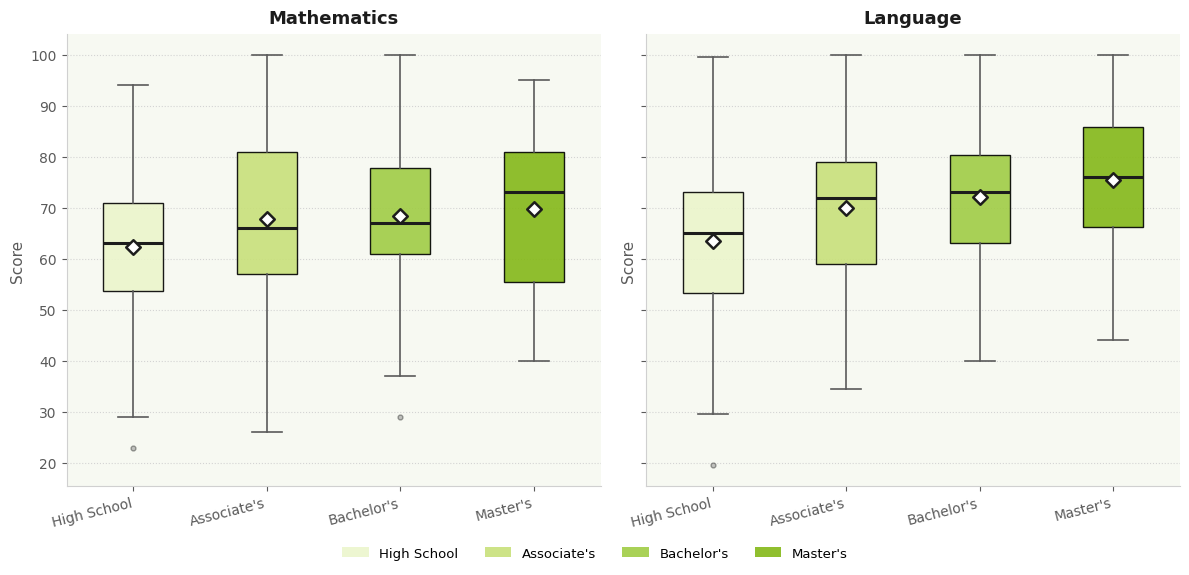

In [14]:
# ── Figure 3: Boxplots — parental education × subject ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True)
fig.patch.set_facecolor(TUD["white"])

for ax, (sdf, title) in zip(axes, [(math, "Mathematics"), (lang, "Language")]):
    groups = [sdf[sdf["parental.level.of.education"] == e]["score"].values
              for e in EDU_ORDER]
    bp = ax.boxplot(groups, **BP_PROPS)
    for box, col in zip(bp["boxes"], EDU_COLORS):
        box.set_facecolor(col); box.set_alpha(0.90)
    for i, g in enumerate(groups, start=1):
        ax.scatter(i, np.mean(g), marker="D", color=TUD["white"],
                   edgecolors=TUD["charcoal"], linewidths=1.8, zorder=6, s=55)
    ax.set_xticks(range(1, 5))
    ax.set_xticklabels(EDU_LABELS, fontsize=9.5, rotation=14, ha="right")
    style_ax(ax, title=title)

edu_patches = [mpatches.Patch(facecolor=c, label=l, alpha=0.90)
               for c, l in zip(EDU_COLORS, EDU_LABELS)]
fig.legend(handles=edu_patches, loc="lower center", ncol=4,
           frameon=False, fontsize=9.5, bbox_to_anchor=(0.5, -0.05))
fig.tight_layout()
save_fig("fig3_edu_boxplots")
plt.show()

✓ figures/fig4_means_ci.pdf  +  figures/fig4_means_ci.png  saved


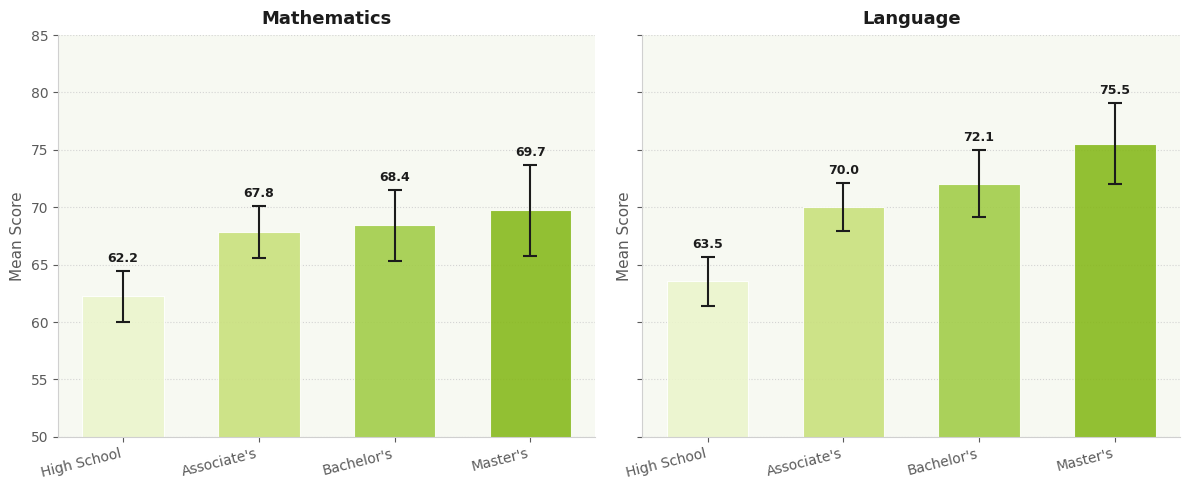

In [15]:
# ── Figure 4: Mean ± 95% CI bar chart — education × subject ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
fig.patch.set_facecolor(TUD["white"])

for ax, (sdf, title) in zip(axes, [(math, "Mathematics"), (lang, "Language")]):
    means, cis = [], []
    for e in EDU_ORDER:
        g = sdf[sdf["parental.level.of.education"] == e]["score"]
        se = g.std() / np.sqrt(len(g))
        means.append(g.mean())
        cis.append(stats.t.ppf(0.975, len(g) - 1) * se)

    x = np.arange(len(EDU_ORDER))
    ax.bar(x, means, color=EDU_COLORS, alpha=0.88,
           edgecolor=TUD["white"], linewidth=0.8, width=0.6)
    ax.errorbar(x, means, yerr=cis, fmt="none", color=TUD["charcoal"],
                capsize=5, capthick=1.5, elinewidth=1.5)
    for i, (m, ci) in enumerate(zip(means, cis)):
        ax.text(i, m + ci + 0.8, f"{m:.1f}", ha="center",
                fontsize=9, fontweight="bold", color=TUD["charcoal"])
    ax.set_xticks(x)
    ax.set_xticklabels(EDU_LABELS, fontsize=9.5, rotation=14, ha="right")
    ax.set_ylim(50, 85)
    style_ax(ax, title=title, ylabel="Mean Score")

fig.tight_layout()
save_fig("fig4_means_ci")
plt.show()

✓ figures/fig5_qq_plots.pdf  +  figures/fig5_qq_plots.png  saved


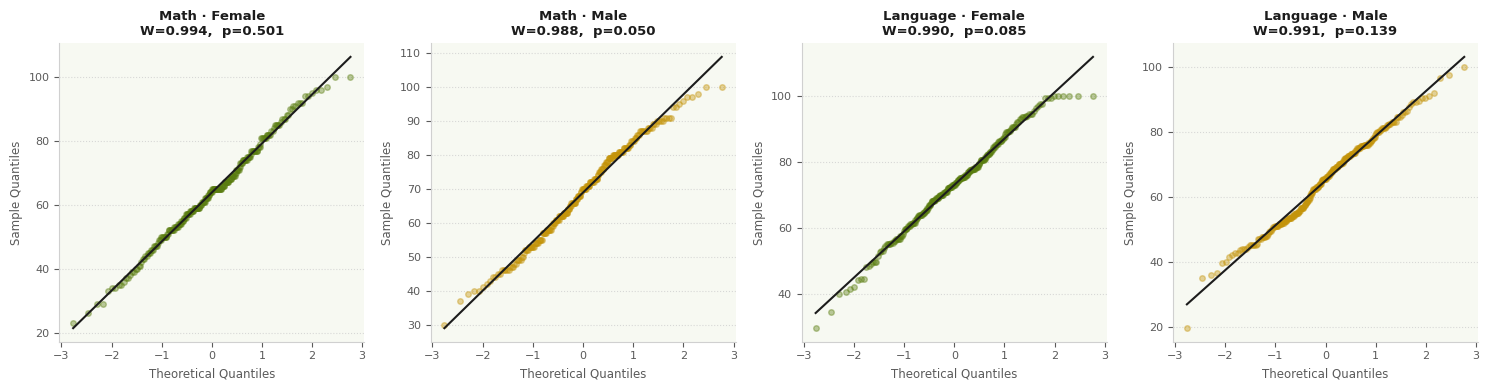

In [16]:
# ── Figure 5: Q-Q plots — gender × subject ────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
fig.patch.set_facecolor(TUD["white"])

combos = [
    (math, "Math",     "female", GENDER_COLORS["female"]),
    (math, "Math",     "male",   GENDER_COLORS["male"]),
    (lang, "Language", "female", GENDER_COLORS["female"]),
    (lang, "Language", "male",   GENDER_COLORS["male"]),
]

for ax, (sdf, subj, grp, col) in zip(axes, combos):
    data = sdf[sdf["gender"] == grp]["score"]
    (osm, osr), (slope, intercept, _) = stats.probplot(data, dist="norm")
    ax.plot(osm, osr, "o", color=col, alpha=0.40, markersize=4)
    ax.plot(osm, np.array(osm) * slope + intercept,
            color=TUD["charcoal"], lw=1.5)
    W, p = stats.shapiro(data)
    ax.set_title(f"{subj} · {grp.capitalize()}\nW={W:.3f},  p={p:.3f}",
                 fontsize=9.5, fontweight="bold", color=TUD["charcoal"])
    ax.set_xlabel("Theoretical Quantiles", fontsize=8.5, color=TUD["slate"])
    ax.set_ylabel("Sample Quantiles",      fontsize=8.5, color=TUD["slate"])
    ax.tick_params(labelsize=8, colors=TUD["slate"])
    ax.yaxis.grid(True, linestyle=":", color=TUD["silver"], alpha=0.8)
    ax.set_facecolor(TUD["bg"])
    for sp in ["top", "right"]: ax.spines[sp].set_visible(False)
    for sp in ["left", "bottom"]:
        ax.spines[sp].set_color(TUD["silver"]); ax.spines[sp].set_linewidth(0.8)

fig.tight_layout()
save_fig("fig5_qq_plots")
plt.show()

## 5 · Assumption Checks

In [17]:
rows = []
for subj, sdf in [("Mathematics", math), ("Language", lang)]:
    for g in ["female", "male"]:
        data = sdf[sdf["gender"] == g]["score"]
        W, p = stats.shapiro(data)
        rows.append({"Subject": subj, "Group": g.capitalize(),
                     "n": len(data), "W": round(W, 4), "p-value": round(p, 4),
                     "Reject H₀ (α=0.05)": "Yes" if p < 0.05 else "No"})

print("── Shapiro-Wilk: Gender Groups ───────────────────────────────────────────")
pd.DataFrame(rows)

── Shapiro-Wilk: Gender Groups ───────────────────────────────────────────


,Subject,Group,n,W,p-value,Reject H₀ (α=0.05)
0,Mathematics,Female,245,0.9944,0.5010,No
1,Mathematics,Male,241,0.9885,0.0505,No
2,Language,Female,245,0.9899,0.0853,No
3,Language,Male,241,0.9909,0.1390,No


In [18]:
rows = []
for subj, sdf in [("Mathematics", math), ("Language", lang)]:
    for e in EDU_ORDER:
        data = sdf[sdf["parental.level.of.education"] == e]["score"]
        W, p = stats.shapiro(data)
        rows.append({"Subject": subj, "Education": e,
                     "n": len(data), "W": round(W, 4), "p-value": round(p, 4),
                     "Reject H₀": "Yes ⚠️" if p < 0.05 else "No"})

print("── Shapiro-Wilk: Education Groups ───────────────────────────────────────")
pd.DataFrame(rows)

── Shapiro-Wilk: Education Groups ───────────────────────────────────────


,Subject,Education,n,W,p-value,Reject H₀
0,Mathematics,high school,156,0.9904,0.3692,No
1,Mathematics,associate's degree,177,0.9846,0.0490,Yes ⚠️
2,Mathematics,bachelor's degree,94,0.9887,0.6086,No
3,Mathematics,master's degree,59,0.9559,0.0317,Yes ⚠️
4,Language,high school,156,0.9884,0.2232,No
5,Language,associate's degree,177,0.9875,0.1202,No
6,Language,bachelor's degree,94,0.9858,0.4078,No
7,Language,master's degree,59,0.9816,0.5121,No


In [19]:
print("── Levene Test: Variance Homogeneity ─────────────────────────────────────")
print()
print("Gender groups:")
for subj, sdf in [("Mathematics", math), ("Language", lang)]:
    f = sdf[sdf["gender"] == "female"]["score"]
    m = sdf[sdf["gender"] == "male"]["score"]
    stat, p = stats.levene(f, m)
    print(f"  {subj:<14}  F = {stat:.4f},  p = {p:.4f}  →  "
          f"{'✓ Do not reject H₀' if p >= 0.05 else '⚠️ Reject H₀'}")
print()
print("Education groups:")
for subj, sdf in [("Mathematics", math), ("Language", lang)]:
    groups = [sdf[sdf["parental.level.of.education"] == e]["score"].values
              for e in EDU_ORDER]
    stat, p = stats.levene(*groups)
    print(f"  {subj:<14}  F = {stat:.4f},  p = {p:.4f}  →  "
          f"{'✓ Do not reject H₀' if p >= 0.05 else '⚠️ Reject H₀'}")

── Levene Test: Variance Homogeneity ─────────────────────────────────────

Gender groups:
  Mathematics     F = 0.0060,  p = 0.9382  →  ✓ Do not reject H₀
  Language        F = 0.1596,  p = 0.6897  →  ✓ Do not reject H₀

Education groups:
  Mathematics     F = 1.2748,  p = 0.2824  →  ✓ Do not reject H₀
  Language        F = 0.1693,  p = 0.9171  →  ✓ Do not reject H₀


## 6 · Gender Hypothesis Tests (RQ1)
**Test:** Welch two-sample *t*-test  
**H₀:** μ_female = μ_male &emsp; **H₁:** μ_female ≠ μ_male &emsp; **α = 0.05**


In [20]:
rows = []
for subj, sdf in [("Mathematics", math), ("Language", lang)]:
    f = sdf[sdf["gender"] == "female"]["score"]
    m = sdf[sdf["gender"] == "male"]["score"]
    t, p   = stats.ttest_ind(f, m, equal_var=False)
    diff   = f.mean() - m.mean()
    se     = np.sqrt(f.var(ddof=1)/len(f) + m.var(ddof=1)/len(m))
    nu_num = (f.var(ddof=1)/len(f) + m.var(ddof=1)/len(m))**2
    nu_den = ((f.var(ddof=1)/len(f))**2/(len(f)-1) +
               (m.var(ddof=1)/len(m))**2/(len(m)-1))
    ci     = stats.t.ppf(0.975, nu_num/nu_den) * se
    rows.append({
        "Subject":     subj,
        "μ Female":    f"{f.mean():.2f}",
        "μ Male":      f"{m.mean():.2f}",
        "Δ (F − M)":   f"{diff:+.2f}",
        "95% CI":      f"[{diff-ci:.2f}, {diff+ci:.2f}]",
        "t":           f"{t:.3f}",
        "p-value":     f"{p:.2e}",
        "Significant": "✓ Yes" if p < 0.05 else "No",
    })

print("── Welch t-test Results ──────────────────────────────────────────────────")
pd.DataFrame(rows).set_index("Subject")

── Welch t-test Results ──────────────────────────────────────────────────


,μ Female,μ Male,Δ (F − M),95% CI,t,p-value,Significant
Subject,,,,,,,
Mathematics,63.86,68.95,-5.09,"[-7.74, -2.44]",-3.778,1.78e-04,✓ Yes
Language,73.00,64.93,+8.07,"[5.60, 10.55]",6.410,3.47e-10,✓ Yes


## 7 · Parental Education Hypothesis Tests (RQ2)
**Primary:** One-way ANOVA + Tukey HSD &emsp; **Robustness:** Kruskal-Wallis &emsp; **α = 0.05**


In [21]:
anova_rows = []
for subj, sdf in [("Mathematics", math), ("Language", lang)]:
    groups = [sdf[sdf["parental.level.of.education"] == e]["score"].values
              for e in EDU_ORDER]
    F, p   = stats.f_oneway(*groups)
    grand  = sdf["score"].values
    ss_b   = sum(len(g)*(g.mean()-grand.mean())**2 for g in groups)
    eta2   = ss_b / sum((grand - grand.mean())**2)
    anova_rows.append({
        "Subject":     subj,
        "F(3, 482)":   f"{F:.3f}",
        "p-value":     f"{p:.2e}",
        "η²":          f"{eta2:.4f}",
        "Significant": "✓ Yes" if p < 0.05 else "No",
    })

print("── One-Way ANOVA ─────────────────────────────────────────────────────────")
pd.DataFrame(anova_rows).set_index("Subject")

── One-Way ANOVA ─────────────────────────────────────────────────────────


,"F(3, 482)",p-value,η²,Significant
Subject,,,,
Mathematics,6.223,3.75e-04,0.0373,✓ Yes
Language,14.241,6.62e-09,0.0814,✓ Yes


In [22]:
for subj, sdf in [("Mathematics", math), ("Language", lang)]:
    print(f"── Tukey HSD: {subj} ──────────────────────────────────────────────────")
    tk = pairwise_tukeyhsd(sdf["score"], sdf["parental.level.of.education"])
    print(tk.summary())
    print()

── Tukey HSD: Mathematics ──────────────────────────────────────────────────


            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2      meandiff p-adj   lower    upper  reject
----------------------------------------------------------------------------
associate's degree bachelor's degree   0.6226 0.9877  -4.2525  5.4977  False
associate's degree       high school    -5.57 0.0037  -9.7649 -1.3751   True
associate's degree   master's degree   1.9322 0.8217  -3.8102  7.6746  False
 bachelor's degree       high school  -6.1926 0.0079 -11.1802  -1.205   True
 bachelor's degree   master's degree   1.3096 0.9512   -5.035  7.6542  False
       high school   master's degree   7.5022 0.0055   1.6639 13.3404   True
----------------------------------------------------------------------------

── Tukey HSD: Language ──────────────────────────────────────────────────


            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2      meandiff p-adj   lower    upper  reject
----------------------------------------------------------------------------
associate's degree bachelor's degree   2.0359 0.6596  -2.5337  6.6055  False
associate's degree       high school  -6.4905 0.0001 -10.4226 -2.5585   True
associate's degree   master's degree   5.5028 0.0429   0.1202 10.8854   True
 bachelor's degree       high school  -8.5265    0.0 -13.2016 -3.8514   True
 bachelor's degree   master's degree   3.4669 0.4365  -2.4802   9.414  False
       high school   master's degree  11.9934    0.0    6.521 17.4658   True
----------------------------------------------------------------------------



In [23]:
print("── Kruskal-Wallis Robustness Check ───────────────────────────────────────")
for subj, sdf in [("Mathematics", math), ("Language", lang)]:
    groups = [sdf[sdf["parental.level.of.education"] == e]["score"].values
              for e in EDU_ORDER]
    H, p = stats.kruskal(*groups)
    match = "✓ agrees with ANOVA" if p < 0.05 else "⚠️ disagrees"
    print(f"  {subj:<14}  H = {H:.3f},  p = {p:.4f}  →  {match}")

── Kruskal-Wallis Robustness Check ───────────────────────────────────────
  Mathematics     H = 15.680,  p = 0.0013  →  ✓ agrees with ANOVA
  Language        H = 36.708,  p = 0.0000  →  ✓ agrees with ANOVA


## 8 · Effect Sizes
- **Hedges' g** — bias-corrected standardised mean difference (gender)  
  `|g| ≈ 0.2` small · `0.5` moderate · `0.8` large *(Cohen 1988)*  
- **η²** — proportion of variance explained by group membership (education)


In [24]:
rows = []
for subj, sdf in [("Mathematics", math), ("Language", lang)]:
    f   = sdf[sdf["gender"] == "female"]["score"]
    m   = sdf[sdf["gender"] == "male"]["score"]
    n1, n2 = len(f), len(m)
    sp  = np.sqrt(((n1-1)*f.var(ddof=1) + (n2-1)*m.var(ddof=1)) / (n1+n2-2))
    g   = (f.mean()-m.mean()) / sp * (1 - 3/(4*(n1+n2-2)-1))

    all_s  = sdf["score"].values
    groups = [sdf[sdf["parental.level.of.education"] == e]["score"].values
              for e in EDU_ORDER]
    ss_b   = sum(len(gr)*(gr.mean()-all_s.mean())**2 for gr in groups)
    eta2   = ss_b / sum((all_s - all_s.mean())**2)

    rows.append({
        "Subject":            subj,
        "Hedges' g (gender)": f"{g:+.3f}",
        "Interpretation":     "small-to-mod." if 0.2 <= abs(g) < 0.5 else "moderate",
        "η² (edu.)":          f"{eta2:.4f}",
        "Interpretation ":    "small-to-mod." if eta2 >= 0.06 else "small",
    })

pd.DataFrame(rows).set_index("Subject")

,Hedges' g (gender),Interpretation,η² (edu.),Interpretation
Subject,,,,
Mathematics,-0.342,small-to-mod.,0.0373,small
Language,+0.581,moderate,0.0814,small-to-mod.


## 9 · Results Summary

In [25]:
summary = pd.DataFrame({
    "RQ": [
        "RQ1 — Gender × Mathematics",
        "RQ1 — Gender × Language",
        "RQ2 — Education × Mathematics",
        "RQ2 — Education × Language",
    ],
    "Test": [
        "Welch t-test", "Welch t-test",
        "ANOVA + Tukey HSD", "ANOVA + Tukey HSD",
    ],
    "Statistic": ["t = −3.778", "t = 6.410", "F(3,482) = 6.223", "F(3,482) = 14.241"],
    "p-value":   ["< 0.001",   "< 0.001",   "< 0.001",           "< 0.001"],
    "Effect":    [
        "g = −0.34  (small-to-mod.)",
        "g = +0.58  (moderate)",
        "η² = 0.037 (small)",
        "η² = 0.081 (small-to-mod.)",
    ],
    "Key Finding": [
        "Males score +5.1 pts higher on average",
        "Females score +8.1 pts higher on average",
        "High school group < all college groups",
        "High school < all college; Master's > Associate's",
    ],
}).set_index("RQ")

print("━" * 70)
print("  FINAL RESULTS SUMMARY")
print("━" * 70)
summary

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  FINAL RESULTS SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Test,Statistic,p-value,Effect,Key Finding
RQ,,,,,
RQ1 — Gender × Mathematics,Welch t-test,t = −3.778,< 0.001,g = −0.34 (small-to-mod.),Males score +5.1 pts higher on average
RQ1 — Gender × Language,Welch t-test,t = 6.410,< 0.001,g = +0.58 (moderate),Females score +8.1 pts higher on average
RQ2 — Education × Mathematics,ANOVA + Tukey HSD,"F(3,482) = 6.223",< 0.001,η² = 0.037 (small),High school group < all college groups
RQ2 — Education × Language,ANOVA + Tukey HSD,"F(3,482) = 14.241",< 0.001,η² = 0.081 (small-to-mod.),High school < all college; Master's > Associate's


---
## ✅ Notebook complete

**Findings:**
- **RQ1:** Males score higher in Mathematics (Δ = +5.1, g = −0.34), females higher in Language (Δ = +8.1, g = +0.58). Both significant at p < 0.001.
- **RQ2:** High school group scores significantly lower than all college groups in both subjects. In Language, Master's additionally outperforms Associate's.
- All results are **associations** — observational data, no causal claims.

**Repo structure:**
```
student-scores-analysis/
├── data/
│   └── Scores.csv
├── notebooks/
│   └── analysis.ipynb
├── figures/
│   ├── fig1_histograms.pdf/.png
│   ├── fig2_gender_boxplots.pdf/.png
│   ├── fig3_edu_boxplots.pdf/.png
│   ├── fig4_means_ci.pdf/.png
│   └── fig5_qq_plots.pdf/.png
├── report/
│   ├── report_final.pdf
│   └── report_final.tex
├── requirements.txt
└── README.md
```
